使用5分K、日盤資料

In [1]:
import pandas as pd

df = pd.read_csv(f"TXF_1T.csv", index_col=0)
df.index = pd.to_datetime(df.index)

df = df.resample('5T', label='right', closed='right').agg(
    {'Open'  :'first',
     'High'  :'max',
     'Low'   :'min',
     'Close' :'last',
     'Volume':'sum',
     '大戶買進' :'sum',
     '散戶買進' :'sum',
     '大戶掛單' :'sum',
     '散戶掛單' :'sum'
    })

df = df.fillna(method='ffill')
df= df.between_time('08:44:59', '13:45:01') #日盤
# df= df.between_time('14:59:59', '05:00:01') #夜盤
# df = pd.concat([df.between_time('14:59:59', '05:00:01'), df.between_time('08:44:59', '13:45:01')]).sort_values(by=["ts"]) #日盤+夜盤


多單策略：RSI<20買進，RSI>80賣出

In [2]:
from backtesting import Strategy
from backtesting.lib import crossover
import talib as ta
from datetime import time

class RSI(Strategy):    

    def init(self):
         self.RSI=self.I(ta.RSI, self.data.Close)

    def next(self):
        if (self.data.index[-1].time() < time(13, 30)) and (self.data.index[-1].time() >= time(8, 45)) and (not self.position.is_long): #日盤期間且未持倉
            if self.RSI[-1]<20 :# 若RSI<20多單進場
                self.buy(size=1)

        elif self.position.is_long: 
            if self.RSI[-1]>80 : #若RSI>80出場
                self.position.close() #平倉

        if self.data.index[-1].time() >= time(13, 30) and self.position.is_long : 
                self.position.close() #平倉


回測此策略

In [3]:
from backtesting import Backtest
bt = Backtest(df, RSI, cash=500000, commission=0.000033, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
#bt.plot(resample=False)

Start                     2020-03-22 08:50:00
End                       2024-01-29 13:45:00
Duration                   1408 days 04:55:00
Exposure Time [%]                   17.244148
Equity Final [$]                498470.367441
Equity Peak [$]                 500459.564802
Return [%]                          -0.305927
Buy & Hold Return [%]              100.409111
Return (Ann.) [%]                    -0.07934
Volatility (Ann.) [%]                0.176573
Sharpe Ratio                              0.0
Sortino Ratio                             0.0
Calmar Ratio                              0.0
Max. Drawdown [%]                   -0.508602
Avg. Drawdown [%]                   -0.040127
Max. Drawdown Duration     1323 days 03:25:00
Avg. Drawdown Duration       70 days 00:10:00
# Trades                                  296
Win Rate [%]                        44.932432
Best Trade [%]                       2.089088
Worst Trade [%]                     -3.303703
Avg. Trade [%]                    

Row(id='1475', ...)

印出權益曲線圖

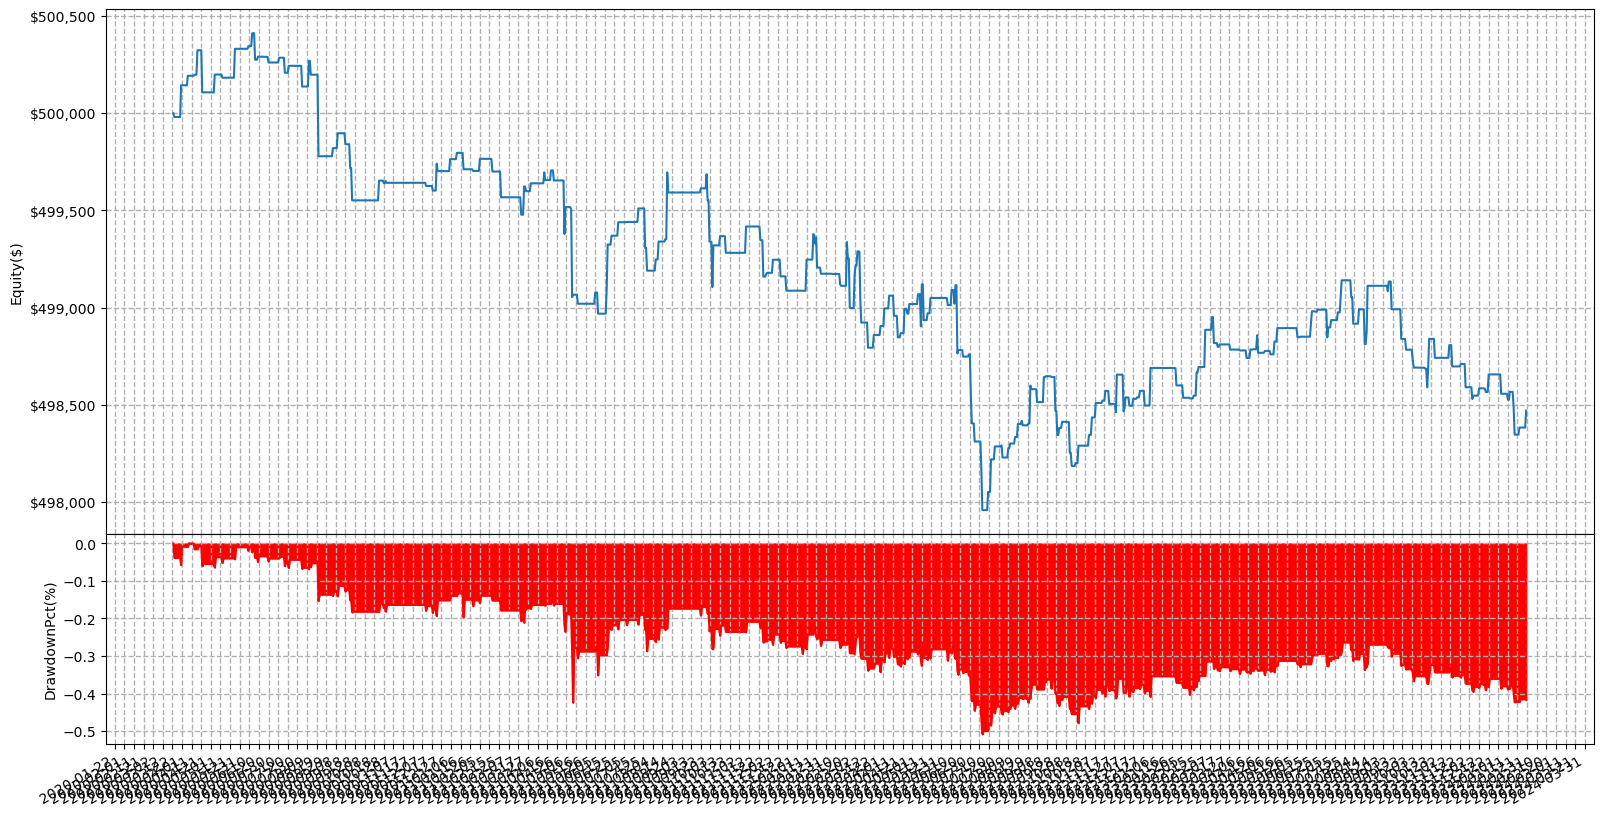

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.ticker import StrMethodFormatter
from backtesting.lib import _EQUITY_AGG

def figure(strategy):   

    equity_data = strategy._equity_curve.resample('1D', label='right').agg(_EQUITY_AGG).dropna(how='all')
    equity_data['DrawdownPct'] = equity_data['DrawdownPct'].multiply(-100)

    f, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(19.2, 10.8), gridspec_kw={'height_ratios': [5, 2]})

    ax1.grid(linestyle = '--', linewidth = 1)
    ax1.plot(equity_data['Equity'])
    ax1.set(ylabel="Equity($)")
    ax1.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    date_form = DateFormatter("%Y-%m-%d")
    ax1.xaxis.set_major_formatter(date_form)
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=10))
    ax2.grid(linestyle = '--', linewidth = 1)
    ax2.plot(equity_data['DrawdownPct'], color="red")
    ax2.set(ylabel="DrawdownPct(%)")
    ax2.fill_between(equity_data['DrawdownPct'].index, equity_data['DrawdownPct'], where=(equity_data['DrawdownPct'] <= 0), color="red")   
    f.subplots_adjust(hspace=0)
    f.autofmt_xdate()
    plt.show()

figure(stats)

加入空單策略

Start                     2020-03-22 08:50:00
End                       2024-01-29 13:45:00
Duration                   1408 days 04:55:00
Exposure Time [%]                   42.139433
Equity Final [$]                503032.003608
Equity Peak [$]                 504059.197919
Return [%]                           0.606401
Buy & Hold Return [%]              100.409111
Return (Ann.) [%]                    0.156736
Volatility (Ann.) [%]                0.285785
Sharpe Ratio                         0.548439
Sortino Ratio                        0.885585
Calmar Ratio                         0.336904
Max. Drawdown [%]                   -0.465225
Avg. Drawdown [%]                    -0.01613
Max. Drawdown Duration      785 days 22:10:00
Avg. Drawdown Duration        7 days 04:09:00
# Trades                                 1193
Win Rate [%]                        38.893546
Best Trade [%]                       3.957648
Worst Trade [%]                     -3.303703
Avg. Trade [%]                    

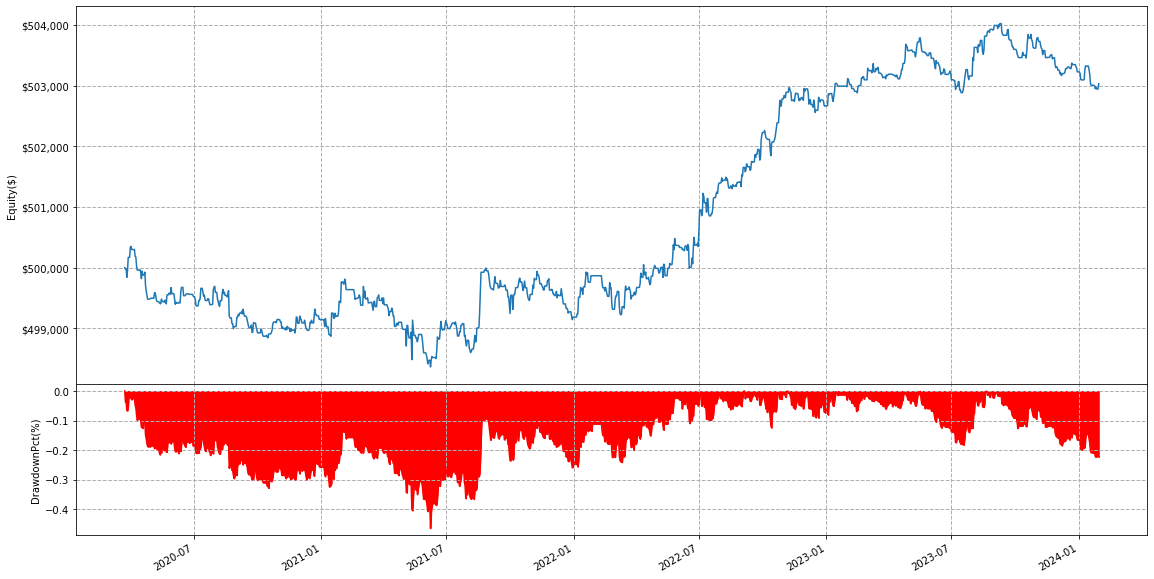

In [5]:
class RSI(Strategy):    

    def init(self):
         self.RSI=self.I(ta.RSI, self.data.Close)

    def next(self):
        if (self.data.index[-1].time() < time(13, 30)) and (self.data.index[-1].time() >= time(8, 45)) and (not self.position.is_long) and (not self.position.is_short): #日盤期間且未持倉
            if self.RSI[-1]<20 :# 若RSI<20多單進場
                self.buy(size=1)
            elif self.data.大戶買進[-1]<-100: #若大戶買進<-100空單進場
                self.sell(size=1)

        elif self.position.is_long: 
            if self.RSI[-1]>80 : #若RSI>80多單出場
                self.position.close() #平倉
                
        elif self.position.is_short:
            if self.data.大戶買進[-1]>100:#若大戶買進>100空單出場
                self.position.close() #平倉

        if self.data.index[-1].time() >= time(13, 30) and (self.position.is_long or self.position.is_short): 
                self.position.close() #平倉

bt = Backtest(df, RSI, cash=500000, commission=0.000033, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
bt.plot(resample=False)
figure(stats)

加入停損

Start                     2020-03-22 08:50:00
End                       2024-01-29 13:45:00
Duration                   1408 days 04:55:00
Exposure Time [%]                   40.007912
Equity Final [$]                503444.382185
Equity Peak [$]                 503877.976802
Return [%]                           0.688876
Buy & Hold Return [%]              100.409111
Return (Ann.) [%]                    0.177999
Volatility (Ann.) [%]                0.268477
Sharpe Ratio                         0.662997
Sortino Ratio                        1.146644
Calmar Ratio                         0.456229
Max. Drawdown [%]                   -0.390153
Avg. Drawdown [%]                   -0.021691
Max. Drawdown Duration      368 days 23:00:00
Avg. Drawdown Duration       10 days 11:49:00
# Trades                                 2182
Win Rate [%]                        26.306141
Best Trade [%]                       4.091859
Worst Trade [%]                     -1.294026
Avg. Trade [%]                    

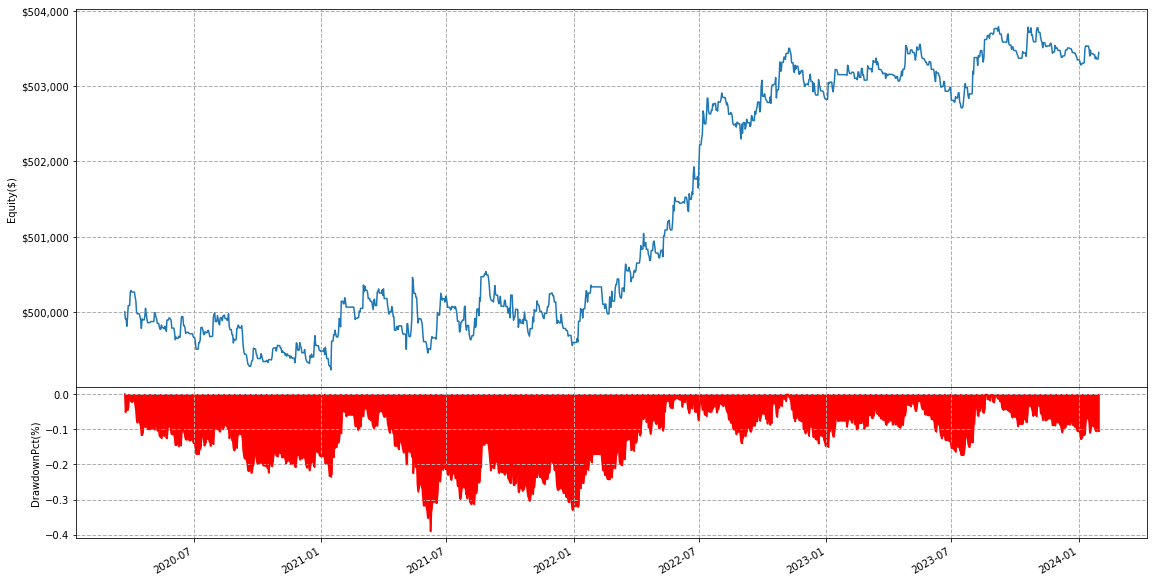

In [6]:
class RSI(Strategy): 
    stop_pct = 1   #表示0.1%

    def init(self):
         self.RSI=self.I(ta.RSI, self.data.Close)

    def next(self):
        if (self.data.index[-1].time() < time(13, 30)) and (self.data.index[-1].time() >= time(8, 45)) and (not self.position.is_long) and (not self.position.is_short): #日盤期間且未持倉
            if self.RSI[-1]<20 :# 若RSI<20多單進場
                self.buy(size=1)
            elif self.data.大戶買進[-1]<-100: #若大戶買進<-100空單進場
                self.sell(size=1)

        elif self.position.is_long: 
            if self.RSI[-1]>80 : #若RSI>80多單出場
                self.position.close() #平倉
            elif self.position.pl_pct < -(self.stop_pct * 0.001): #當前虧損百分比超過停損參數時
                self.position.close() #平倉
                
        elif self.position.is_short:
            if self.data.大戶買進[-1]>100:#若大戶買進>100空單出場
                self.position.close() #平倉
            elif self.position.pl_pct < -(self.stop_pct * 0.001): #當前虧損百分比超過停損參數時
                self.position.close() #平倉

        if self.data.index[-1].time() >= time(13, 30) and (self.position.is_long or self.position.is_short): 
                self.position.close() #平倉

bt = Backtest(df, RSI, cash=500000, commission=0.000033, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
bt.plot(resample=False)
figure(stats)

最佳化參數

Start                     2020-03-22 08:50:00
End                       2022-12-31 13:45:00
Duration                   1014 days 04:55:00
Exposure Time [%]                   42.481507
Equity Final [$]                503083.439842
Equity Peak [$]                 503275.657146
Return [%]                           0.616688
Buy & Hold Return [%]               55.860239
Return (Ann.) [%]                    0.221328
Volatility (Ann.) [%]                 0.29684
Sharpe Ratio                         0.745616
Sortino Ratio                        1.250695
Calmar Ratio                         0.706013
Max. Drawdown [%]                    -0.31349
Avg. Drawdown [%]                   -0.018769
Max. Drawdown Duration      406 days 22:20:00
Avg. Drawdown Duration        7 days 23:51:00
# Trades                                 1310
Win Rate [%]                        31.679389
Best Trade [%]                       4.091859
Worst Trade [%]                     -1.294026
Avg. Trade [%]                    

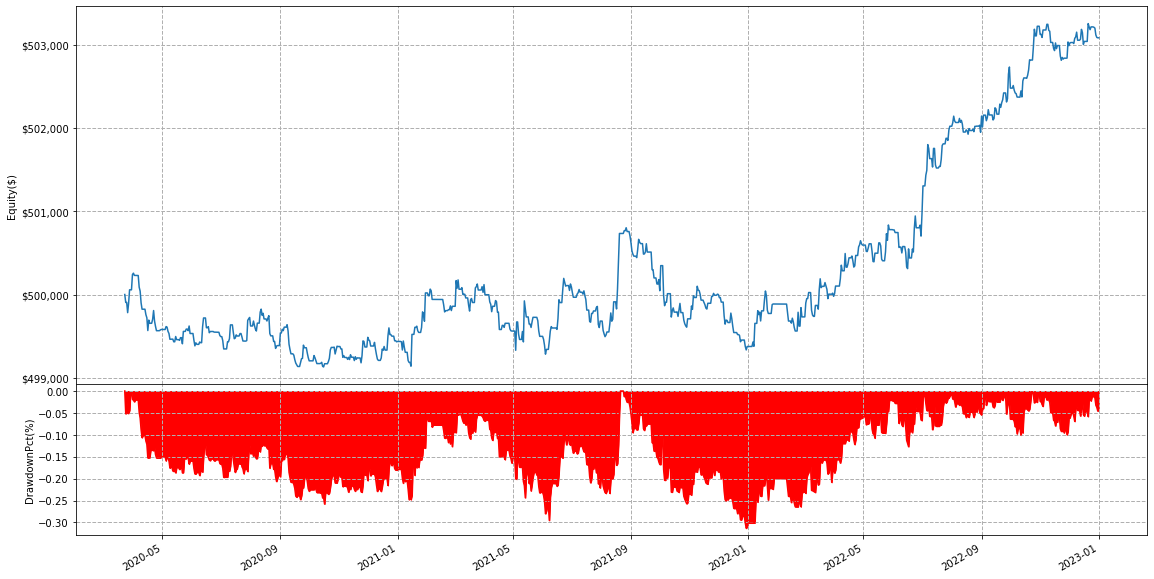

In [7]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, RSI, cash=500000, commission=0.000033, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(stop_pct=range(1,4,1))
print(stats_op)
figure(stats_op)

將最佳化的結果代入策略中，回測樣本內外的數據

Start                     2020-03-22 08:50:00
End                       2024-01-29 13:45:00
Duration                   1408 days 04:55:00
Exposure Time [%]                   40.991064
Equity Final [$]                504036.526543
Equity Peak [$]                 504615.011896
Return [%]                           0.807305
Buy & Hold Return [%]              100.409111
Return (Ann.) [%]                    0.208509
Volatility (Ann.) [%]                0.273357
Sharpe Ratio                         0.762773
Sortino Ratio                        1.287536
Calmar Ratio                         0.665121
Max. Drawdown [%]                    -0.31349
Avg. Drawdown [%]                   -0.017391
Max. Drawdown Duration      406 days 22:20:00
Avg. Drawdown Duration        7 days 07:56:00
# Trades                                 1694
Win Rate [%]                        32.467532
Best Trade [%]                       4.091859
Worst Trade [%]                     -1.294026
Avg. Trade [%]                    

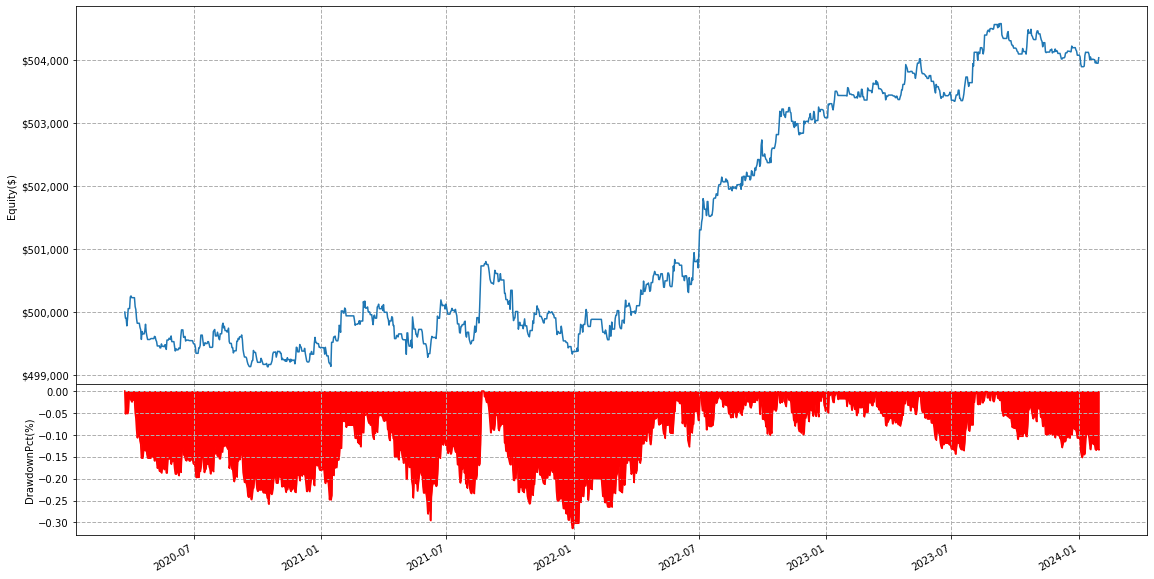

In [8]:
class RSI(Strategy): 
    stop_pct = 2   #最佳化後的結果

    def init(self):
         self.RSI=self.I(ta.RSI, self.data.Close)

    def next(self):
        if (self.data.index[-1].time() < time(13, 30)) and (self.data.index[-1].time() >= time(8, 45)) and (not self.position.is_long) and (not self.position.is_short): #日盤期間且未持倉
            if self.RSI[-1]<20 :# 若RSI<20多單進場
                self.buy(size=1)
            elif self.data.大戶買進[-1]<-100: #若大戶買進<-100空單進場
                self.sell(size=1)

        elif self.position.is_long: 
            if self.RSI[-1]>80 : #若RSI>80多單出場
                self.position.close() #平倉
            elif self.position.pl_pct < -(self.stop_pct * 0.001): #當前虧損百分比超過停損參數時
                self.position.close() #平倉
                
        elif self.position.is_short:
            if self.data.大戶買進[-1]>100:#若大戶買進>100空單出場
                self.position.close() #平倉
            elif self.position.pl_pct < -(self.stop_pct * 0.001): #當前虧損百分比超過停損參數時
                self.position.close() #平倉

        if self.data.index[-1].time() >= time(13, 30) and (self.position.is_long or self.position.is_short): 
                self.position.close() #平倉

bt = Backtest(df, RSI, cash=500000, commission=0.000033, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
bt.plot(resample=False)
figure(stats)